In [1]:
'''
Simulation of MECT phantoms
'''

'\nSimulation of MECT phantoms\n'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import SimpleITK as sitk

import pcct_md_diffusion.utils as utils
from pcct_md_diffusion.fbp import additional_fbp_filter
from pcct_md_diffusion.utils import load_nist_attenuation, load_mixture_attenuation_from_composition_file
from pcct_md_diffusion.locations import base_input_dir

In [3]:
# load material attenuation data
df_att = load_mixture_attenuation_from_composition_file(
    os.path.join(base_input_dir, 'omnitom_pcd/calibration/material_composition.csv'),
    os.path.join(base_input_dir, 'spectrum/NIST'),
    kevs=np.arange(30, 120 + 1, 1)
)

df_water = load_nist_attenuation(
    os.path.join(base_input_dir, 'spectrum/NIST/water.txt'),
    kevs=np.arange(30, 120 + 1, 1)
)

df_att['true_water'] = df_water['mu']

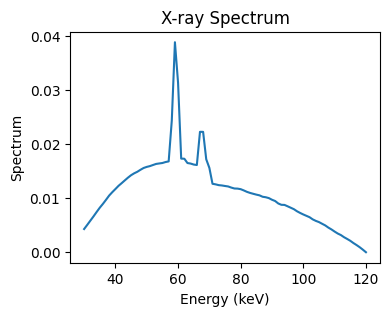

In [4]:
# load spectrum
df_spec = pd.read_csv(os.path.join(base_input_dir, 'spectrum/xray/spektr_120kVp_Be2p0_Cu0p127_omnitom.csv'))
df_spec = df_spec[(df_spec['Energy_keV'] >= 30) & (df_spec['Energy_keV'] <= 120)].reset_index(drop=True)
spectrum = df_spec['Photons'].values
spectrum = spectrum / np.sum(spectrum)  # normalize to sum to 1

df_spec = pd.DataFrame({
    'energy': df_spec['Energy_keV'],
    'spectrum': spectrum
})

plt.figure(figsize=(4, 3))
plt.plot(df_spec['energy'], df_spec['spectrum'])
plt.xlabel('Energy (keV)')
plt.ylabel('Spectrum')
plt.title('X-ray Spectrum')
plt.show()

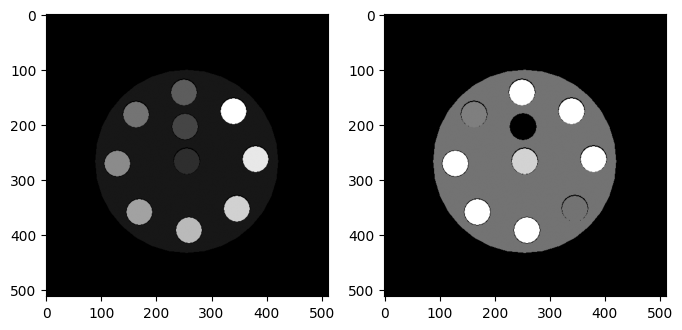

In [5]:
# load phantom
calibration_dir = os.path.join(base_input_dir, 'omnitom_pcd/calibration/calibration_8_41/img/1')
sitk_mask = sitk.ReadImage(os.path.join(calibration_dir, 'segmentation.seg.nrrd'))
dx, dy, dz = sitk_mask.GetSpacing()
mask = sitk.GetArrayFromImage(sitk_mask)[[0]]

# load phantom material labels
df_mask = pd.read_csv(os.path.join(calibration_dir, 'materials.csv'))

# compose a 60keV phantom
img_mono_60 = np.zeros_like(mask, dtype=np.float32)
for _, row in df_mask.iterrows():
    label = row['Seg']
    material = row['Material']
    mu = df_att[df_att['energy'] == 60][material].values[0]
    img_mono_60[mask == label] = mu

# water attenuation at 60keV
mu_water_60 = df_att[df_att['energy'] == 60]['true_water'].values[0]

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(mask[0], 'gray')

plt.subplot(1, 2, 2)
plt.imshow(img_mono_60[0], 'gray', vmin=mu_water_60-0.001, vmax=mu_water_60 + 0.001)
plt.show()


In [ ]:
# load geometry
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
geometry_path = os.path.join(base_input_dir, 'omnitom_pcd/geometry/omnitom_3x3_parallel_fov_308.cfg')
geo = utils.load_geometry(geometry_path)
geo.nx = mask.shape[-1]
geo.ny = mask.shape[-2]
geo.nz = mask.shape[-3]
geo.nv = geo.nz
geo.dx = dx
geo.dy = dy
geo.dz = dz
geo.dv = dz
leapct = utils.set_leapct_geometry(geo)
# geo.nu *= 2
# geo.du /= 2
# geo.nview = 720
# geo.off_u = 0
# leapct = utils.set_leapct_geometry(geo, angles_in_deg=np.arange(0, 180, 180.0 / geo.nview).astype(np.float32))
leapct.print_parameters()

AttributeError: 'tomographicModels' object has no attribute 'astype'

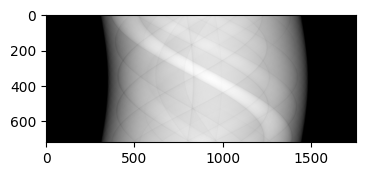

In [ ]:
# forward project each material and make the ploychromatic projection
current_fp = leapct.allocate_projections()
prjs_materials = []
for i in range(len(df_mask)):
    label = df_mask.loc[i, 'Seg']
    material = df_mask.loc[i, 'Material']
    img_material = np.where(mask == label, 1, 0).astype(np.float32)
    _ = leapct.project(current_fp, img_material)
    prjs_materials.append(current_fp.copy())
prjs_materials = np.array(prjs_materials)

# prjs = np.sum(prjs_materials, axis=0)

# the attenuation coefficient of each material at each energy
mus_materials = []
for i in range(len(df_mask)):
    material = df_mask.loc[i, 'Material']
    # material = 'water'
    mus_materials.append(df_att[material].values)
mus_materials = np.array(mus_materials)

# composite the polychromatic projection
attenuation = np.sum(prjs_materials[..., None] * mus_materials[:, None, None, None, :], axis=0)
prjs_poly = -np.log(np.sum(spectrum * np.exp(-attenuation), axis=-1)).astype(np.float32)
# prjs_poly = -np.log(np.sum(np.exp(-prjs[..., None] * df_att['water'].values) * spectrum, axis=-1)).astype(np.float32)

plt.figure(figsize=(4, 3))
plt.imshow(prjs_poly[:, 0, :], 'gray')


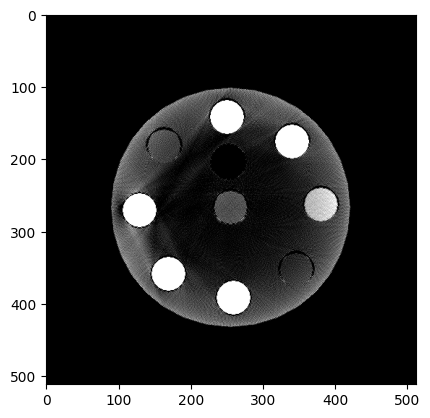

In [ ]:
# reconstruction
recon_poly = leapct.FBP(prjs_poly)
plt.imshow(recon_poly[0], 'gray', vmin=mu_water_60-0.001, vmax=mu_water_60 + 0.001)

Fitted water attenuation: 0.019770, True water attenuation at 60keV: 0.020590
[ 9.47615279e-01  1.46685734e-02 -6.09879097e-04]


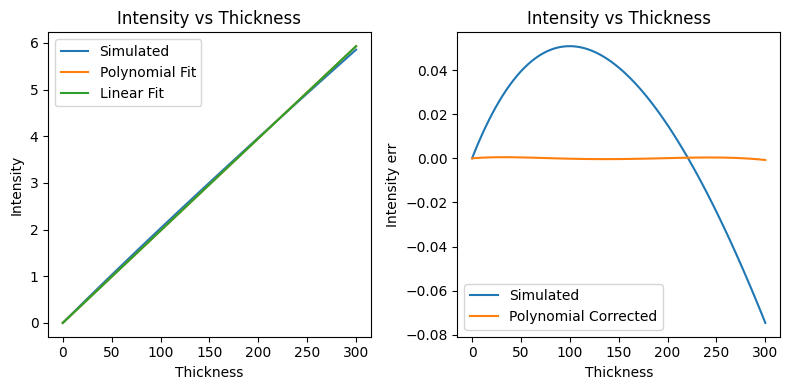

In [ ]:
# test polynomial BHC using 30cm of water phantom
thicknesses = np.linspace(0, 300, 100)  # mm
attenuation = df_att['water'].values * thicknesses[:, None]
intensity = -np.log(np.sum(spectrum * np.exp(-attenuation), axis=-1))
intensity[intensity < 0] = 0

# expected water attenuation: fit with y = kx
water_att = np.linalg.lstsq(thicknesses[:, None], intensity, rcond=None)[0][0]
print(f'Fitted water attenuation: {water_att:.6f}, True water attenuation at 60keV: {mu_water_60:.6f}')

# use 3-order polynomial fit without intercept
order = 3
A = np.vstack([intensity**i for i in range(1, order + 1)]).T
b = water_att * thicknesses
coeffs = np.linalg.lstsq(A, b, rcond=None)[0]
print(coeffs)

# apply polynomial BHC
intensity_fit = np.sum(coeffs[:, None] * np.vstack([intensity**i for i in range(1, order + 1)]), axis=0)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.plot(thicknesses, intensity, label='Simulated')
plt.plot(thicknesses, intensity_fit, label='Polynomial Fit')
plt.plot(thicknesses, water_att * thicknesses, label='Linear Fit')
plt.xlabel('Thickness')
plt.ylabel('Intensity')
plt.title('Intensity vs Thickness')
plt.legend()
plt.tight_layout()

plt.subplot(1, 2, 2)
plt.plot(thicknesses, intensity - water_att * thicknesses, label='Simulated')
plt.plot(thicknesses, intensity_fit - water_att * thicknesses, label='Polynomial Corrected')
plt.xlabel('Thickness')
plt.ylabel('Intensity err')
plt.title('Intensity vs Thickness')
plt.legend()
plt.tight_layout()

plt.show()

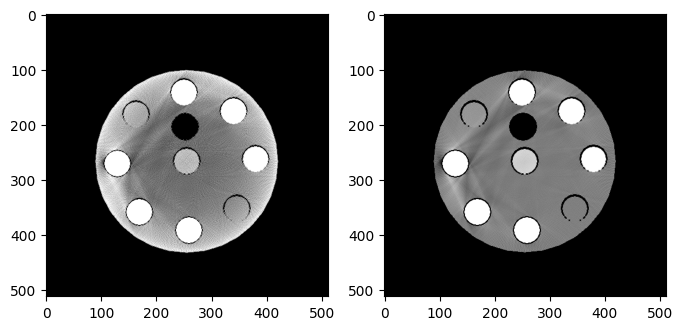

In [ ]:
# apply correction to the projection data
prjs_fit = np.sum(coeffs[:, None, None, None] * np.array([prjs_poly**i for i in range(1, order + 1)]), axis=0).astype(np.float32)
prjs_fit = additional_fbp_filter(prjs_fit)
recon_fit = leapct.FBP(prjs_fit)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(recon_poly[0], cmap='gray', vmin=water_att - 0.001, vmax=water_att + 0.001)
plt.subplot(1, 2, 2)
plt.imshow(recon_fit[0], cmap='gray', vmin=water_att - 0.001, vmax=water_att + 0.001)

In [ ]:
# convert recon_fit to HU and save nii
recon_fit_hu = (recon_fit / water_att * 1000 - 1000).astype(np.int16)
sitk_recon = sitk.GetImageFromArray(recon_fit_hu)
sitk_recon.SetSpacing(sitk_mask.GetSpacing())
sitk_recon.SetOrigin(sitk_mask.GetOrigin())
sitk_recon.SetDirection(sitk_mask.GetDirection())
sitk.WriteImage(sitk_recon, os.path.join(calibration_dir, 'recon_fit.nii.gz'))